In [47]:
import numpy as np
import pickle
import scipy.signal as signal
import matplotlib.pyplot as plt
from astropy.io import fits

# Reading pickle files
with open('particles.pickle', 'rb') as part_file:
    particles = pickle.load(part_file)
with open('weights.pickle', 'rb') as weight_file:
    weights= pickle.load(weight_file)

Mdust = 1e-5 # Msun
distance = 3.4e3 # in pc (as particles in in arcsec)
rmin=100 # sublimation distance for ISM dust [au]

P = particles.T * distance # au

# filtering particle that are too close to the star
r = np.sqrt(P[:,0]**2 + P[:,1]**2 + P[:,2]**2)
ou = np.where(r>rmin)[0]
P = P[ou,:]
weights = weights[ou]

# normalising particle masses
weights *= Mdust/np.sum(weights)

# Writing data to fits file for mcfost
hdu1 = fits.PrimaryHDU(weights)

hdu2 = fits.ImageHDU(P* (1 + 1e-3* (np.random.rand(len(weights), 3)*2-1) )) # positions in au
hdul=fits.HDUList([hdu1,hdu2])
hdul.writeto("wrcube.fits", overwrite=True)


In [51]:
# Slicing a smaller array for testing
n=10
weights_small = weights[0::n]
P_small = P[0::n,:]

hdu1 = fits.PrimaryHDU(weights_small)

hdu2 = fits.ImageHDU(P_small* (1 + 1e-3* (np.random.rand(len(weights_small), 3)*2-1) )) # positions in au
hdul=fits.HDUList([hdu1,hdu2])
hdul.writeto("wrcube2.fits", overwrite=True)

In [28]:
def spiral_grid(particles, weights, stardata):
    ''' Takes in the particle positions and weights and calculates the 2D histogram, ignoring those points at (0,0,0), and
        applying a Gaussian blur.
    Parameters
    ----------
    particles : ndarray (Ndim, Nparticles)
        Particle positions in cartesian coordinates
    weights : array (Nparticles)
        Weight of each particle in the histogram (for orbital/azimuthal variations)
    sigma : 
    '''
    im_size = 256
    
    x = particles[0, :]
    y = particles[1, :]
    
    weights = np.where((x != 0) & (y != 0), weights, 0)
    
    H, xedges, yedges = np.histogram2d(x, y, bins=im_size, weights=weights)
    X, Y = np.meshgrid(xedges, yedges)
    H = H.T
    H /= np.max(H)
    
    H = np.minimum(H, np.ones((im_size, im_size)) * stardata['histmax'])
    
    shape = 30 // 2  # choose just large enough grid for our gaussian
    gx, gy = np.meshgrid(np.arange(-shape, shape+1, 1), np.arange(-shape, shape+1, 1))
    gxy = np.exp(- (gx*gx + gy*gy) / (2 * stardata['sigma']**2))
    gxy /= gxy.sum()
    
    H = signal.convolve(H, gxy, mode='same', method='fft')
    
    H /= np.max(H)
    H = H**stardata['lum_power']
    
    return X, Y, H

def plot_spiral(X, Y, H):
    ''' Plots the histogram given by X, Y edges and H densities
    '''
    fig, ax = plt.subplots()
    ax.set_facecolor('k')
    ax.pcolormesh(X, Y, H, cmap='hot')
    ax.set(aspect='equal', xlabel='Relative RA (")', ylabel='Relative Dec (")')

In [29]:
# below are rough params for WR 112
WR112 = {"m1":15.,                # solar masses
        "m2":10.,                # solar masses
        "eccentricity":0., 
        "inclination":100.,       # degrees
        "asc_node":360-75.,         # degrees
        "arg_peri":170.,           # degrees
        "open_angle":110.,       # degrees (full opening angle)
        "period":19,           # years
        "distance":2400,        # pc
        "windspeed1":700,       # km/s
        "windspeed2":2400,      # km/s
        "turn_on":-180,         # true anomaly (degrees)
        "turn_off":180,         # true anomaly (degrees)
        "oblate":0.,
        "nuc_dist":0.1, "opt_thin_dist":0.2,           # nucleation and optically thin distance (AU)
        "acc_max":1e-9,                               # maximum acceleration (km/s/yr)
        "orb_sd":0., "orb_amp":0., "orb_min":180, "az_sd":0., "az_amp":0., "az_min":90, 
        "comp_incl":0, "comp_az":0, "comp_open":0, "comp_reduction":0., "comp_plume":0,
        "phase":0.6, 
        "sigma":2,              # sigma for gaussian blur
        "histmax":0.03, "lum_power":1.3, 
        "spin_inc":0., "spin_Omega":0., "spin_oa_mult":0., "spin_vel_mult":0., "spin_oa_sd":0.1, "spin_vel_sd":0.1}

/var/folders/l_/77d1mrnd3tqc6jpy8tsfdnwh0000gr/T/ipykernel_29162/1800003860.py:34: RuntimeWarning: invalid value encountered in power
  H = H**stardata['lum_power']


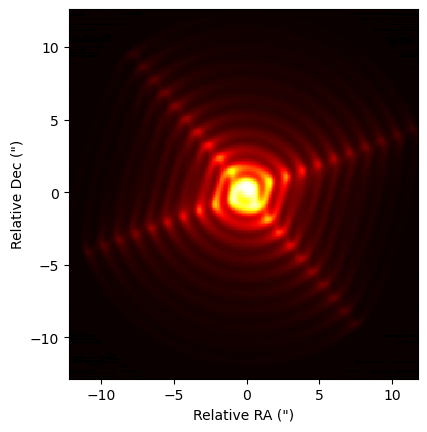

In [30]:
X, Y, H = spiral_grid(particles, weights, WR112)

fig, ax = plt.subplots()
ax.set_facecolor('k')
ax.pcolormesh(X, Y, H, cmap='hot')
ax.set(aspect='equal', xlabel='Relative RA (")', ylabel='Relative Dec (")')
plt.show()